---
title: PSMC
---

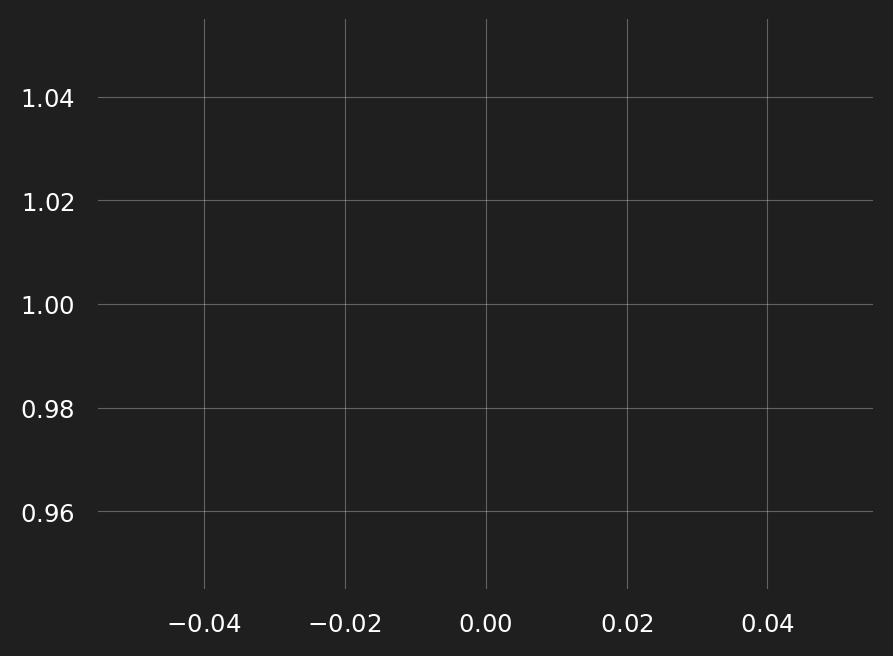

In [1]:
from phasic import (
    Graph, with_ipv, clear_caches
)
import numpy as np
import jax.numpy as jnp
import pandas as pd
from typing import Optional
from functools import partial
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
from tqdm.auto import tqdm
from vscodenb import set_vscode_theme

np.random.seed(42)
set_vscode_theme('dark')
#sns.set_palette('tab10')
plt.close('all')
plt.plot(1) ;

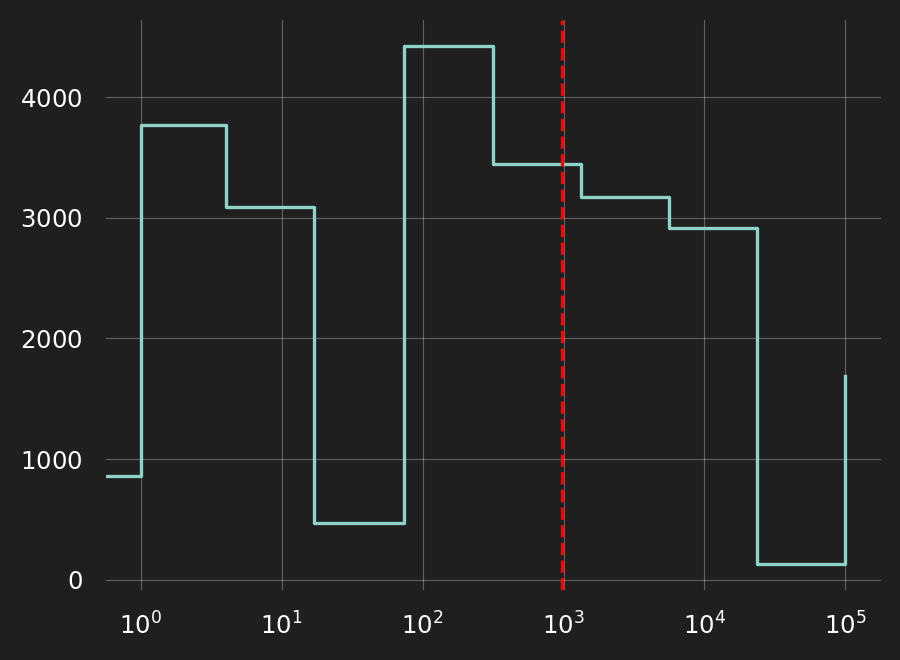

In [2]:

n = 10
sampledemog_data = pd.DataFrame(dict(years=[0]+np.logspace(0, 5, n-1, dtype=int, base=10).tolist(),
                               Ne=np.random.randint(1, 5_000, size=n),
                               population=['pop']*n
                              ))
sampledemog_data.sort_values('years', inplace=True)


def exp_coal(g, N):
    """
    Compute expected coalescence time in epoch
    N is the number of diploid invididuals
    g is the number of generations spanned by the epoch
    """
    return 2*N - (g * np.exp(-g/(2*N))) / (1 - np.exp(-g/(2*N)))

def epoch(demog, h, i):
    "Recursively compute expected coalescence time across all epoches"
    g, N = demog[i]
    N *= h
    if i == len(demog)-1:
        return 2*N
    return (1-np.exp(-g/(2*N))) * exp_coal(g, N) + np.exp(-g/(2*N)) * (g + epoch(demog, h, i+1))

def pool_nielsen(gens, Ne, h):
    """
    Compute expected coalescence time in units of 2N
    Ne is the a list/series of Ne in the epoch.
    gens is the a list/series of generation at which an each epoch begins (the last epoch lasts forever)
    h is the relative population size, 0.75 for chrX.
    """
    epochs = list()
    for i in range(len(gens)):
        if i == 0:
            epochs.append((gens[i+1], Ne[i]))
        elif i == len(gens)-1:
            epochs.append((None, Ne[i]))    
        else:
            epochs.append((gens[i+1] - gens[i], Ne[i]))
    return epoch(epochs, h, 0)

gen_time = 30
exp_coal_time = pool_nielsen(gens=sampledemog_data.years / gen_time, 
                               Ne=sampledemog_data.Ne,
                               h=1)
# pool_nielsen(gens, Ne, 0.75)
plt.step(sampledemog_data.years, sampledemog_data.Ne, where='post')
plt.gca().set_xscale('log')
plt.gca().axvline(exp_coal_time, color='red', linestyle='--')
plt.show()

In [3]:

# """ 
# $$
# p(t \mid s) = \left(1 - e^{-\rho t}\right) q(t \mid s) + e^{-\rho s} \delta(t - s)
# $$

# where

# $$
# q(t \mid s) = \frac{1}{\lambda(t)} \int_0^{\min(s,t)} \frac{1}{s} \times e^{-\int_u^t \frac{1}{\lambda(v)} dv} \, du
# $$
# """


# from scipy import integrate

# def smc_rate(t, s, rho, lambda_func, tol=1e-9):
#     """
#     Compute p(t | s) = (1 - e^{-ρt}) q(t | s) + e^{-ρs} δ(t - s)
    
#     Parameters
#     ----------
#     t : float
#         Time parameter t
#     s : float
#         Time parameter s
#     rho : float
#         Rate parameter ρ
#     lambda_func : callable
#         Function λ(v) that takes a single argument
#     tol : float
#         Tolerance for Kronecker delta comparison
    
#     Returns
#     -------
#     float
#         The value of p(t | s)
#     """

#     def q(t, s, lambda_func):
#         """
#         Compute q(t | s) = (1/λ(t)) * ∫₀^{min(s,t)} (1/s) * exp(-∫ᵤᵗ 1/λ(v) dv) du
#         """
#         upper_limit = min(s, t)
        
#         def integrand(u):
#             inner_integral, _ = integrate.quad(lambda v: 1 / lambda_func(v), u, t)
#             return (1 / s) * np.exp(-inner_integral)
        
#         outer_integral, _ = integrate.quad(integrand, 0, upper_limit)
#         return (1 / lambda_func(t)) * outer_integral
    
#     res = (1 - np.exp(-rho * t)) * q(t, s, lambda_func) + np.exp(-rho * s) * int(s == t)
#     return res.item()

In [4]:

# def psmc(max_run=2):


#     epochs = [(0, 1), (1, 2), (2, np.inf)]

#     ipv = [[[0, 0, i+1, 0, 0], 1/len(epochs)] for i in range(len(epochs))]


#     state_vector_length = 5
#     coeff_size = 4

#     graph = Graph(state_vector_length)

#     for i in range(1, len(epochs)+1):
#         graph.starting_vertex().add_edge(graph.find_or_create_vertex([0, 0, i, 0, 0]), 1/len(epochs))

#     index = len(epochs)





#     child_state = state.copy()
#     coeff = np.zeros(coeff_size, dtype=int)
#     coeff[0] = 1  # mutation coeff only
#     coeff[1] = epoch  # current epoch
#     coeff[2] = epoch  # current epoch
#     vertex.add_edge(graph.find_or_create_vertex(child_state), coeff) # mutation coeff only

#     for to_epoch in range(1, len(epochs)+1):
#         child_state = state.copy()
#         child_state[2] = to_epoch
#         coeff = [0]*coeff_size
#         coeff[1] = epoch
#         coeff[2] = to_epoch
#         vertex.add_edge(graph.find_or_create_vertex(child_state), coeff)






#     while index < graph.vertices_length():

#         vertex = graph.vertex_at(index)
#         state = vertex.state()

#         run_left, run_right, epoch, trash, is_t_state = state

#         if state.sum() == 0:
#             continue

#         if is_t_state:
#             absorbing = np.zeros(state.size, dtype=int)
#             vertex.add_edge(
#                 graph.find_or_create_vertex(absorbing), [0]*coeff_size)
#             continue

#         if trash:
#             # from trash to het
#             child_state = state.copy()
#             child_state[3] = 2 if trash == 1 else 1
#             vertex.add_edge(
#                 graph.find_or_create_vertex(child_state), [0]*coeff_size)
#             continue


#         if not run_right: # no run counts for right, so on left

#             if run_left >= max_run:
#                 # edge to trash
#                 child_state = np.zeros(state.size, dtype=int)
#                 child_state[3] = 1
#                 vertex.add_edge(graph.find_or_create_vertex(child_state), [0]*coeff_size)                
#                 continue

#             # mutation: shortcut to right side
#             child_state = state.copy()
#             coeff = [0]*coeff_size
#             child_state[1] = 1 # run len 1 at left side
#             coeff[0] = 1  # mutation coeff only
#             coeff[1] = epoch  # current epoch
#             coeff[2] = epoch  # current epoch
#             vertex.add_edge(graph.find_or_create_vertex(child_state), coeff) # mutation coeff only
        
#             for to_epoch in range(1, len(epochs)+1):
#                 child_state = state.copy()
#                 child_state[0] += 1 # increment left run
#                 child_state[2] = to_epoch
#                 coeff = [0]*coeff_size
#                 coeff[1] = epoch
#                 coeff[2] = to_epoch
#                 vertex.add_edge(graph.find_or_create_vertex(child_state), coeff)

#         else:
#             if run_right >= max_run:
#                 # edge to trash
#                 coeff = [1, epoch, epoch, 1] 
#                 vertex.add_edge(graph.find_or_create_vertex([0, 0, 0, 1, 0]), [0]*coeff_size)
#                 continue

#     #run_left, run_right, epoch, trash, is_t_state = state

#             # mutation: shortcut to t-state
#             child_state = state.copy()#np.zeros(state.size, dtype=int)
#             child_state[4] = 1 # t-state
#             coeff = [0]*coeff_size
#             coeff[0] = 1  # mutation coeff only
#             coeff[1] = epoch  # current epoch
#             coeff[2] = epoch  # current epoch
#             vertex.add_edge(
#                         graph.find_or_create_vertex(child_state), 
#                         coeff) # mutation coeff only
        
#             for to_epoch in range(1, len(epochs)+1):
#                 child_state = state.copy()
#                 child_state[1] += 1 # increment right run
#                 child_state[2] = to_epoch
#                 coeff = [0]*coeff_size
#                 coeff[2] = to_epoch
#                 coeff[1] = epoch # in this order to overwrite with 1 if same epoch
#                 vertex.add_edge(
#                         graph.find_or_create_vertex(child_state), 
#                         coeff)

#         index += 1
    
#     return graph


# # print(ipv)
# graph = psmc(max_run=2)
# graph.plot(size=(12,20), nodesep=0.2, max_nodes=300
#         #    by_state=lambda state: state[2]
#            )

In [11]:


def update_callback(param, coeff, epochs=None, mu=None):
    """
    states are [run_left, run_right, epoch]
    coefficients are [0, 0, 1, 0, 2]  # 1 for epoch from and to. (2 can be before 1)
    only one number 1 means prob of no rec or rec and coal in same epoch
    """
    if np.sum(coeff) == 0:
        # non-smc transition, always one
        return 1.0

    rec_rate, *N = param
    N.insert(0, 1) # N0 is always 1

    is_mut, from_idx, to_idx, is_one_minus = coeff

    from_idx = int(from_idx)
    to_idx = int(to_idx)

    # mutation_coef, *from_to = coeff
    # from_idx = from_to.index(1)
    # if 2 in from_to:
    #     to_idx = from_to.index(2)
    # else:
    #     to_idx = from_idx

    if is_mut:
        # from_idx only serve to make current tree height available
        rate = is_mut * 2 * N[from_idx] * mu
    else:

        min_t = min(epochs[from_idx][0], epochs[to_idx][0])
        rec_prob = 2 * rec_rate * min_t

        # sample rec event and find rec epoch:
        rec_time = np.random.random() * min_t
        for i, (start, end) in enumerate(epochs):
            if rec_time < end:
                rec_idx = i
                break

        # prob coal in to_epoch given rec in rec_epoch
        coal_prob = 1
        for i in range(rec_idx, to_idx):
            start, end = epochs[i]
            coal_prob *= 1 - np.exp( -1 / N[i] * (end-start) )
        coal_prob *= np.exp(-1/N[to_idx]*(end-start))

        if from_idx == to_idx:
            rate = rec_prob * coal_prob + (1 - rec_prob)
        else:
            rate = rec_prob * coal_prob
    
#        print("->", coal_prob, rec_prob)

    if is_one_minus:
        rate = 1 - rate
    print(rate)
    return rate

# There are some details to be sorted out with rec and coal in same epoch integrating over times
# And integrating over rec times and coal times in each epoch

# epoch times in units of N
# epochs = [(0, 1), (1, 2), (2, 3), (3, 4), (4, np.inf)]
# update_callback = partial(update_callback, epochs=epochs, mu=1e-9)

# # N0 is always 1
# #              rec. N1 N2 N3 N4 N5
# some_param = [0.01, 5, 5, 5, 5, 5]
# for coeff in [
#     [0, 2, 1, 0],
#     [0, 1, 2, 0],
#     [0, 1, 1, 0],
#     [1, 1, 1, 0],
#     [1, 1, 1, 1],
# ]:
#     print(update_callback(some_param, coeff))



# states: [run_left, run_right, epoch, trash]
# params: [recombination_rate, N1, N2, N3, N4, N5]
# coeff: [is_mutation, from_epoch, to_epoch, one_minus]

def psmc(state, max_run=None, epochs=None):

    transitions = []

    run_left, run_right, epoch, trash, is_t_state = state

    coeff_size= 1+ len(epochs)
#    coeff_size= 6

    if state.sum() == 0:
        return []

    if is_t_state:
        absorbing = np.zeros(state.size, dtype=int)
        return [[absorbing, [0]*coeff_size]]



    # mutation: trans to het if left and t-state if right

    if trash:
        # from trash to het
        child_state = state.copy()
        child_state[3] = 2 if trash == 1 else 1
        coeff = [0]*coeff_size
        transitions.append([child_state, coeff]) # mutation coeff only
        return transitions


    if not run_right: # no run counts for right, so on left

        if run_left >= max_run:
            # edge to trash
            child_state = np.zeros(state.size, dtype=int)
            child_state[3] = 1
            transitions.append([child_state, [0]*coeff_size])
            return transitions

        if run_left == 0:
            child_state = state.copy()
            child_state[0] = 1 # run len 1 at left side
            coeff = [0]*coeff_size
            coeff[0] = 0.001  # mutation coeff only
            coeff[1] = epoch  # current epoch
            coeff[2] = epoch  # current epoch
            transitions.append([child_state, coeff]) # mutation coeff only
        
            for to_epoch in range(len(epochs)):
                child_state = state.copy()
                if to_epoch == epoch:
                    continue
                child_state[2] = to_epoch
                coeff = [0]*coeff_size
                coeff[1] = epoch
                coeff[2] = to_epoch
                transitions.append([child_state, coeff])

        else:
            # mutation: shortcut to right side
            child_state = state.copy()
            coeff = [0]*coeff_size
            child_state[1] = 1 # run len 1 at left side
            coeff[0] = 1  # mutation coeff only
            coeff[1] = epoch  # current epoch
            coeff[2] = epoch  # current epoch
            transitions.append([child_state, coeff]) # mutation coeff only
        
            for to_epoch in range(len(epochs)):
                child_state = state.copy()
                child_state[0] += 1 # increment left run
                child_state[2] = to_epoch
                coeff = [0]*coeff_size
                coeff[1] = epoch
                coeff[2] = to_epoch
                transitions.append([child_state, coeff])

    else:
        if run_right >= max_run:
            # edge to trash
            coeff = [1, epoch, epoch, 1] 
            transitions.append([[0, 0, 0, 1, 0], [0]*coeff_size])
            return transitions

#run_left, run_right, epoch, trash, is_t_state = state

        # mutation: shortcut to t-state
        child_state = state.copy()#np.zeros(state.size, dtype=int)
        child_state[4] = 1 # t-state
        coeff = [0]*coeff_size
        coeff[0] = 1  # mutation coeff only
        coeff[1] = epoch  # current epoch
        coeff[2] = epoch  # current epoch
        transitions.append([child_state, coeff]) # mutation coeff only
    
        for to_epoch in range(len(epochs)):
            child_state = state.copy()
            child_state[1] += 1 # increment right run
            child_state[2] = to_epoch
            coeff = [0]*coeff_size
            coeff[2] = to_epoch
            coeff[1] = epoch # in this order to overwrite with 1 if same epoch
            transitions.append([child_state, coeff])

    
    return transitions

# epochs = [(0, 1), (1, 2), (2, 3), (3, 4), (4, np.inf)]
epochs = [(0, 1), (4, np.inf)]
# epochs = [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (8, 9), (9, 10), 
#           (10, 11), (11, 12), (12, 13), (13, 14), (14, 15), (15, 16), (16, 17), (18, 19), (19, 20),
#           (20, np.inf)]


#epochs = [(0, 1), (1, 2), (2, np.inf)]

ipv = [[[0, 0, i+1, 0, 0], 1/len(epochs)] for i in range(len(epochs))]
# print(ipv)

# for max_run in [3]:#, 200, 300, 400, 500]:
#     graph = Graph(psmc, ipv=ipv, max_run=max_run, epochs=epochs)

#     graph.update_weights([1e-4, 1, 2, 1, 3, 2], update_callback)


graph = Graph(psmc, ipv=ipv, max_run=3, epochs=epochs)

update_callback = partial(update_callback, epochs=epochs, mu=1e-9)
graph.update_weights([1e-4, 1, 2], update_callback)

print(graph.vertices_length())

graph.plot(size=(12,8), nodesep=0.2, max_nodes=1000
        #    by_state=lambda state: state[2]
           )

ValueError: not enough values to unpack (expected 4, got 3)

In [ ]:
graph.expectation()

[ERROR] phasic.c: Computation produced NaN at vertex 221 (command 368: from=221 to=255 multiplier=nan result[to]=inf) - numerical catastrophe


RuntimeError: Computation produced NaN at vertex 221 (command 368) - numerical catastrophe

20000000